# Bank Customer Churn Prediction

Gibran Ariq Natakusuma

DSML-41




In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import warnings
import plotly.express as px
from statsmodels.tools.tools import add_constant
from statsmodels.stats.outliers_influence import variance_inflation_factor
from scipy.stats import chi2_contingency
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold, learning_curve
from lazypredict.Supervised import LazyClassifier
from sklearn.ensemble import RandomForestClassifier, BaggingClassifier
from sklearn.tree import DecisionTreeClassifier
import lightgbm as lgb
from sklearn.metrics import confusion_matrix, classification_report, roc_auc_score, accuracy_score, precision_score, recall_score, f1_score, roc_curve

warnings.filterwarnings('ignore')


---
# 1. Data Loading & Understanding

Dataset berisi atribut pelanggan Bank ABC Multistate. Mari kita eksplorasi strukturnya.


This dataset is for ABC Multistate bank with following columns:

Customer ID - The Unique ID of each individual customer 

Credit Score - A number depicting the customer’s credithworthiness

Country - The country the customer banks from

Gender - The gender the customer identifies with

Age - Depicts the customers age

Tenure - Indicates how length in years the customer has been with the bank

Balance - The amount currently available in the customer’s account

Products Number - The number of products purchased by the customer through the bank

Credit Card - Indicates the customer has a credit card

Active Member - Indicates if the customer is an active or inactive

Estimated Salary - Bank Estimation of the income of the customer

Churn - Indicator of if the customer has left the bank or not



In [2]:
df = pd.read_csv('../dataset/Bank Customer Churn Prediction.csv')
df.head(10)

,customer_id,credit_score,country,gender,age,tenure,balance,products_number,credit_card,active_member,estimated_salary,churn
0,15634602,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,15647311,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,15619304,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,15701354,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,15737888,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0
5,15574012,645,Spain,Male,44,8,113755.78,2,1,0,149756.71,1
6,15592531,822,France,Male,50,7,0.00,2,1,1,10062.80,0
7,15656148,376,Germany,Female,29,4,115046.74,4,1,0,119346.88,1
8,15792365,501,France,Male,44,4,142051.07,2,0,1,74940.50,0
9,15592389,684,France,Male,27,2,134603.88,1,1,1,71725.73,0


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 12 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customer_id       10000 non-null  int64  
 1   credit_score      10000 non-null  int64  
 2   country           10000 non-null  object 
 3   gender            10000 non-null  object 
 4   age               10000 non-null  int64  
 5   tenure            10000 non-null  int64  
 6   balance           10000 non-null  float64
 7   products_number   10000 non-null  int64  
 8   credit_card       10000 non-null  int64  
 9   active_member     10000 non-null  int64  
 10  estimated_salary  10000 non-null  float64
 11  churn             10000 non-null  int64  
dtypes: float64(2), int64(8), object(2)
memory usage: 937.6+ KB


In [4]:
df.isna().sum()

customer_id         0
credit_score        0
country             0
gender              0
age                 0
tenure              0
balance             0
products_number     0
credit_card         0
active_member       0
estimated_salary    0
churn               0
dtype: int64

In [5]:
df.duplicated().sum()

0

In [6]:
df.describe()

,customer_id,credit_score,age,tenure,balance,products_number,credit_card,active_member,estimated_salary,churn
count,10000.00,10000.00,10000.00,10000.00,10000.00,10000.00,10000.00,10000.00,10000.00,10000.00
mean,15690940.57,650.53,38.92,5.01,76485.89,1.53,0.71,0.52,100090.24,0.20
std,71936.19,96.65,10.49,2.89,62397.41,0.58,0.46,0.50,57510.49,0.40
min,15565701.00,350.00,18.00,0.00,0.00,1.00,0.00,0.00,11.58,0.00
25%,15628528.25,584.00,32.00,3.00,0.00,1.00,0.00,0.00,51002.11,0.00
50%,15690738.00,652.00,37.00,5.00,97198.54,1.00,1.00,1.00,100193.91,0.00
75%,15753233.75,718.00,44.00,7.00,127644.24,2.00,1.00,1.00,149388.25,0.00
max,15815690.00,850.00,92.00,10.00,250898.09,4.00,1.00,1.00,199992.48,1.00


## Insight: Data Quality
Data terdiri dari **10.000 baris** dengan **12 kolom**. Tidak ditemukan *missing values* maupun data *duplicate*.

- Seluruh fitur numerik memiliki rentang nilai yang wajar - tidak ada nilai negatif yang anomali pada balance maupun estimated_salary.



---
# 2. Exploratory Data Analysis (EDA)

Tahap ini bertujuan memahami distribusi data, hubungan antar fitur, dan pola yang berkaitan dengan target variabel churn.


## 2.1 Feature Engineering untuk Visualisasi

Kita membuat dua fitur segmentasi, credit_segment dan age_segment, **khusus untuk keperluan visualisasi** agar distribusi lebih mudah dipahami. Fitur ini **tidak dimasukkan ke dalam model**.


In [9]:
bins = [0, 580, 670, 740, 800, 851]
labels = ['Poor', 'Fair', 'Good', 'Very good', 'Exceptional']

df['credit_segment'] = pd.cut(df['credit_score'], bins=bins, labels=labels, right=False)

# Cek hasilnya
print(df['credit_segment'].value_counts().sort_index())
df[['credit_score', 'credit_segment']].head(10)

credit_segment
Poor           2362
Fair           3331
Good           2428
Very good      1224
Exceptional     655
Name: count, dtype: int64


,credit_score,credit_segment
0,619,Fair
1,608,Fair
2,502,Poor
3,699,Good
4,850,Exceptional
5,645,Fair
6,822,Exceptional
7,376,Poor
8,501,Poor
9,684,Good


In [10]:
bins = [18, 26, 40, 56, 100]  # Tambahkan batas atas untuk mengakomodasi usia di atas 55
labels = ['Gen Z', 'Millennials', 'Gen X', 'Baby Boomers']

df['age_segment'] = pd.cut(df['age'], bins=bins, labels=labels, right=False)

# Cek hasilnya
print(df['age_segment'].value_counts().sort_index())
df[['age', 'age_segment']].head(10)

age_segment
Gen Z            611
Millennials     5376
Gen X           3213
Baby Boomers     800
Name: count, dtype: int64


,age,age_segment
0,42,Gen X
1,41,Gen X
2,42,Gen X
3,39,Millennials
4,43,Gen X
5,44,Gen X
6,50,Gen X
7,29,Millennials
8,44,Gen X
9,27,Millennials


## 2.2 Distribusi Target & Fitur Numerikal

Sebelum analisis bivariate, mari lihat distribusi kelas target churn dan distribusi fitur numerik utama.


In [11]:
green = '#2ecc71'
red = '#e74c3c'

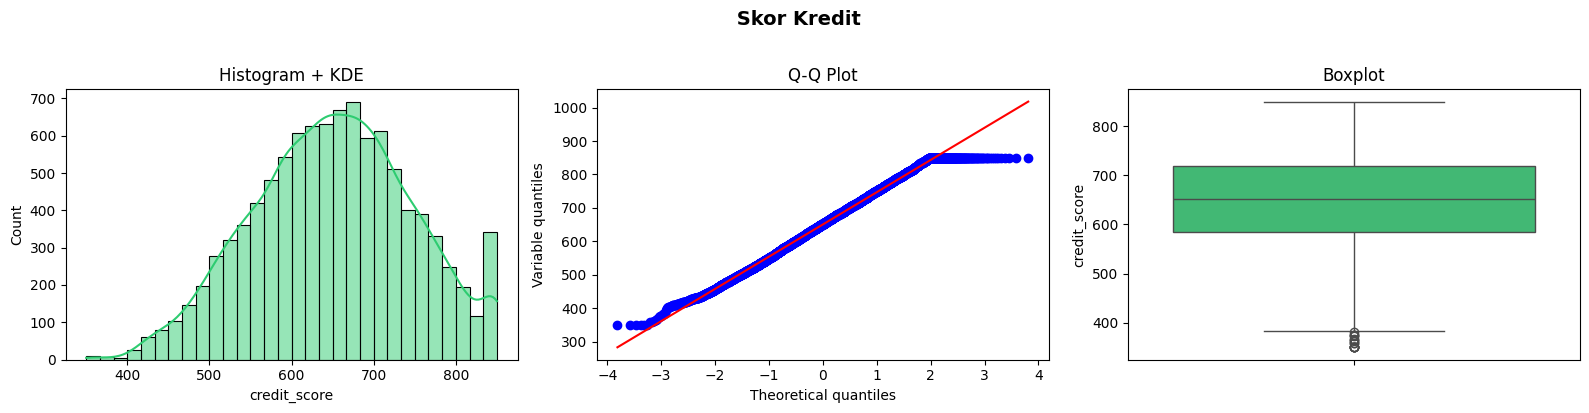

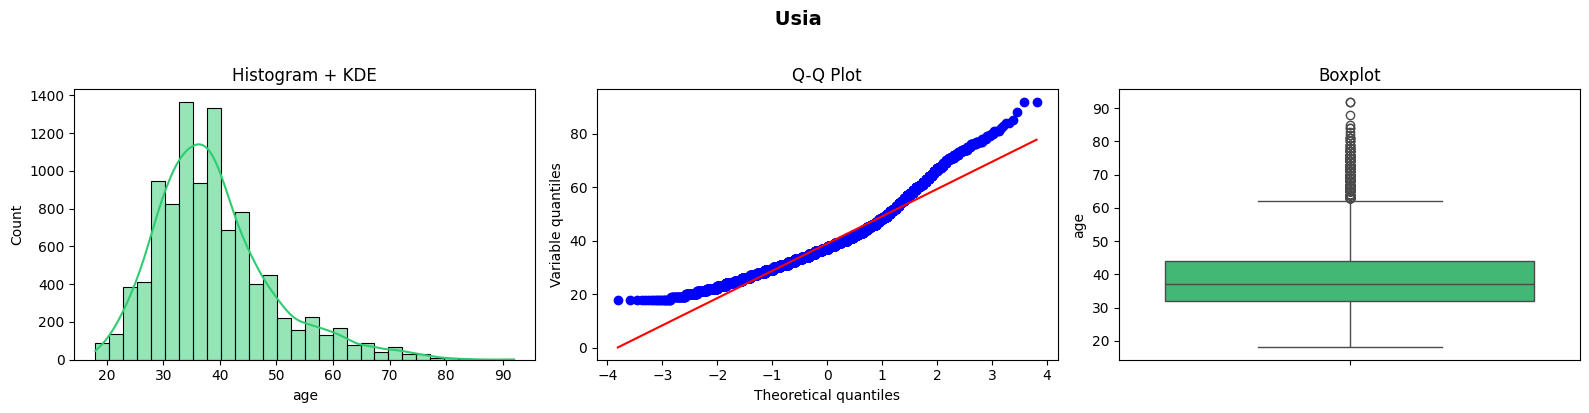

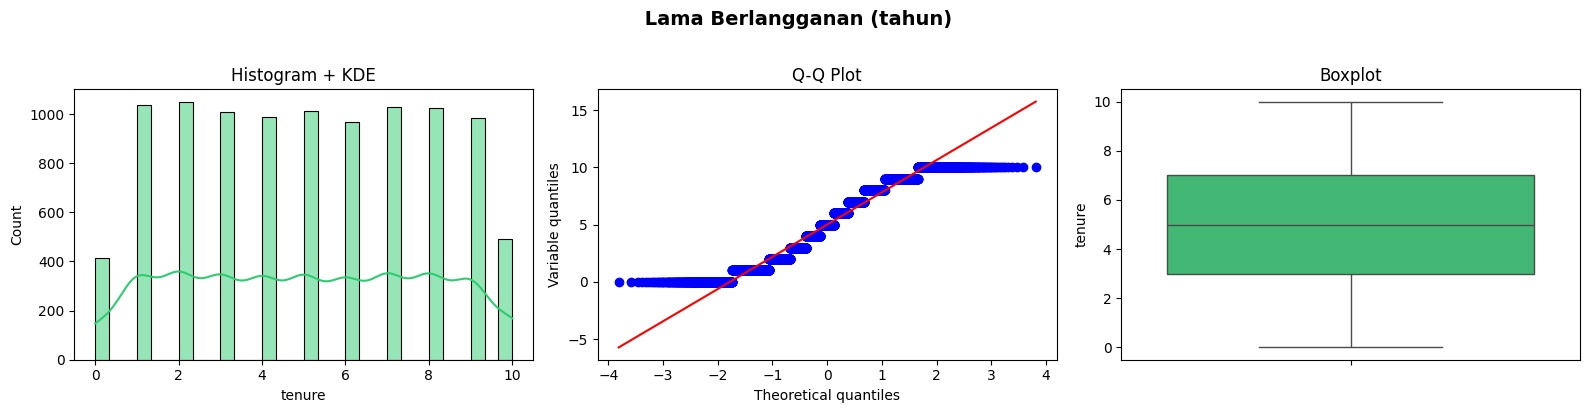

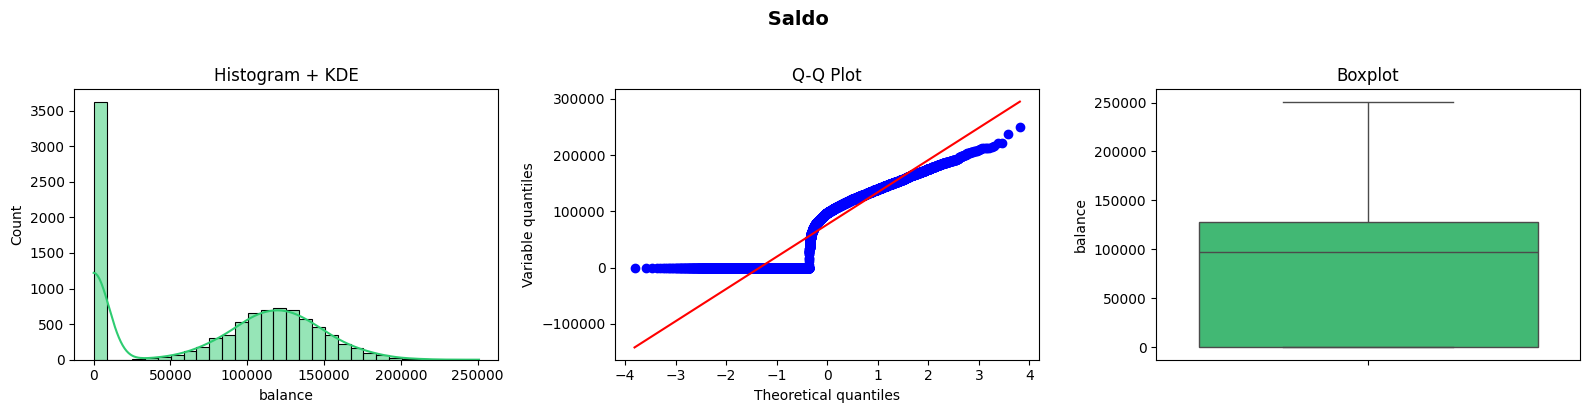

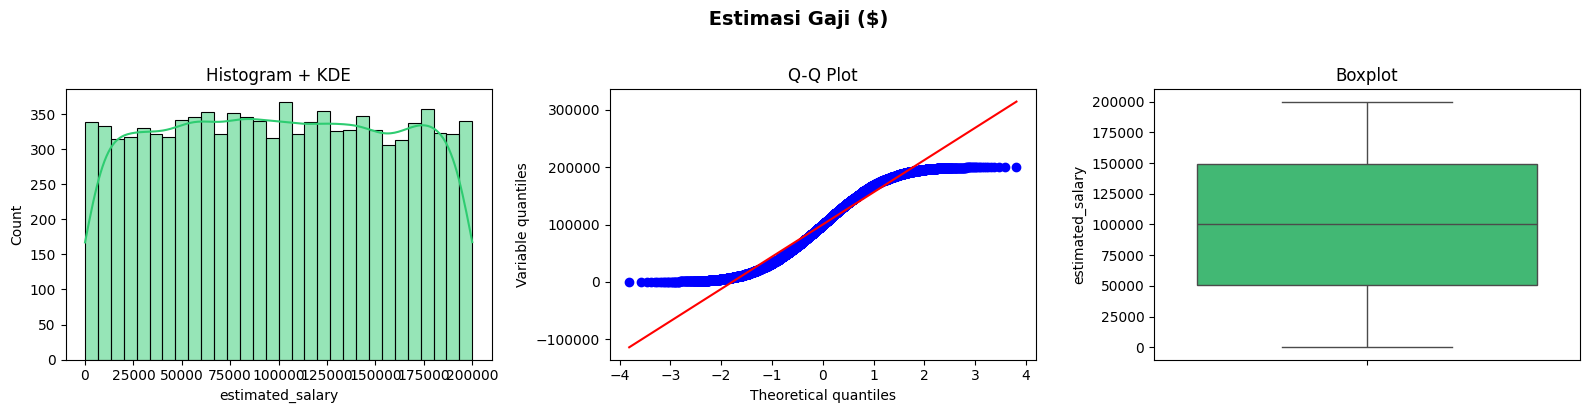

In [12]:
nama_fitur = {
    'credit_score': 'Skor Kredit',
    'age': 'Usia',
    'tenure': 'Lama Berlangganan (tahun)',
    'balance': 'Saldo',
    'estimated_salary': 'Estimasi Gaji ($)'
}

numerik_cols = ['credit_score', 'age', 'tenure', 'balance', 'estimated_salary']

def check_plot(df, columns):
    for variable in columns:
        plt.figure(figsize=(16, 4))
        plt.suptitle(f' {nama_fitur.get(variable, variable)}', fontsize=14, fontweight='bold', y=1.02)
        
        # Histogram
        plt.subplot(1, 3, 1)
        sns.histplot(df[variable], bins=30, kde=True, color=green)
        plt.title('Histogram + KDE')
        plt.xlabel(variable)
        
        # Q-Q Plot
        plt.subplot(1, 3, 2)
        stats.probplot(df[variable], dist="norm", plot=plt)
        plt.title('Q-Q Plot')
        plt.ylabel('Variable quantiles')
        
        # Box Plot
        plt.subplot(1, 3, 3)
        sns.boxplot(y=df[variable], color='#2ecc71')
        plt.title('Boxplot')
        
        plt.tight_layout()
        plt.show()

check_plot(df, numerik_cols)

Tidak diperlukan *imputation* atau penanganan outlier, karena tidak terdapat outlier

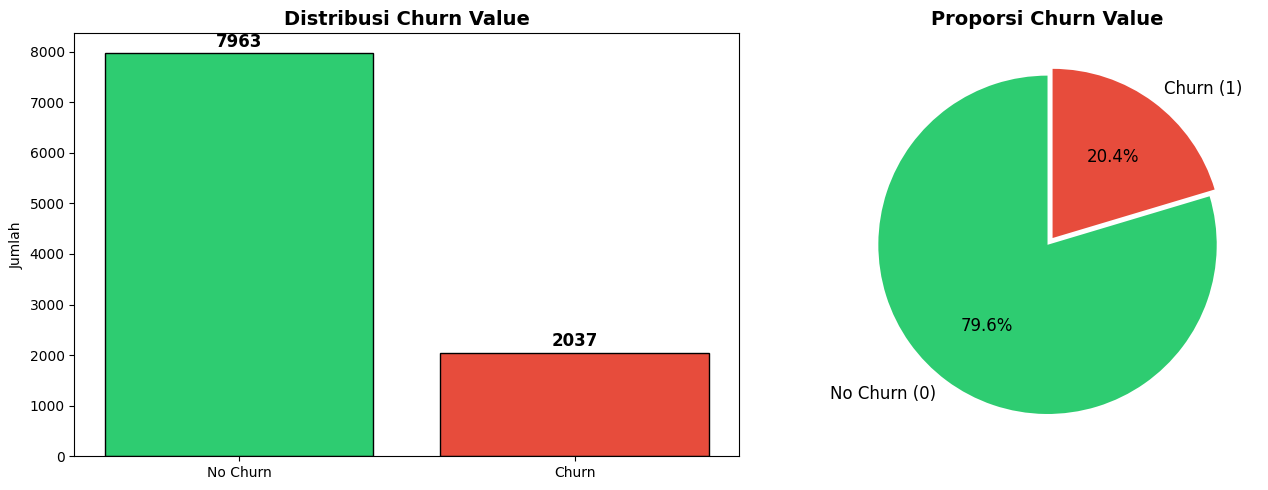

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Bar chart
ax1 = axes[0]
churn_counts = df['churn'].value_counts()
bars = ax1.bar(churn_counts.index.map({0: 'No Churn', 1: 'Churn'}), 
               churn_counts.values, color=['#2ecc71', '#e74c3c'], edgecolor='black')
for bar in bars:
    height = bar.get_height()
    ax1.annotate(f'{int(height)}', xy=(bar.get_x() + bar.get_width() / 2, height),
                xytext=(0, 5), textcoords='offset points', ha='center', fontsize=12, fontweight='bold')
ax1.set_title('Distribusi Churn Value', fontsize=14, fontweight='bold')
ax1.set_ylabel('Jumlah')

# Pie chart
ax2 = axes[1]
ax2.pie(churn_counts.values, labels=['No Churn (0)', 'Churn (1)'], 
        autopct='%1.1f%%', colors=['#2ecc71', '#e74c3c'], startangle=90,
        textprops={'fontsize': 12}, explode=(0, 0.05))
ax2.set_title('Proporsi Churn Value', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.show()

**Insight - Class Imbalance:**
Terdapat *imbalance* pada kelas target: sekitar **80% No Churn** dan **20% Churn**. Rasio ini tidak terlalu ekstrim, sehingga kita tidak menggunakan SMOTE. Sebagai gantinya, kita akan memanfaatkan parameter class_weight='balanced' pada model agar model lebih sensitif terhadap kelas minoritas (Churn).


Text(0.5, 1.0, 'Distribution of Balance by Churn')

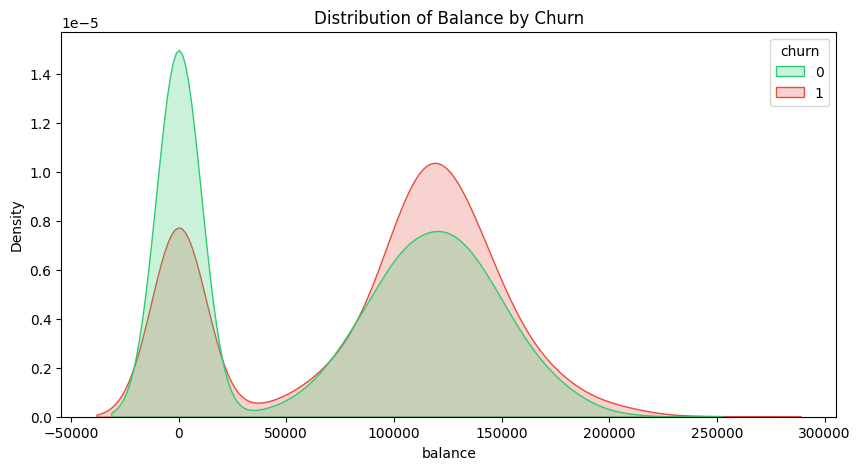

In [14]:
plt.figure(figsize=(10, 5))
sns.kdeplot(data=df, x='balance', hue='churn', fill=True, common_norm=False, palette={0: green, 1: red})
plt.title('Distribution of Balance by Churn')

Text(0.5, 1.0, 'Distribution of Estimated Salary by Churn')

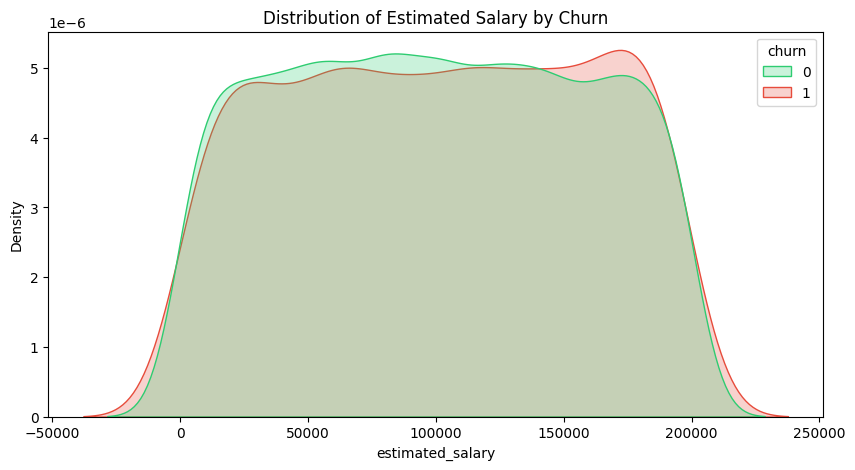

In [15]:
plt.figure(figsize=(10, 5))
sns.kdeplot(data=df, x='estimated_salary', hue='churn', fill=True, common_norm=False, palette={0: green, 1: red})
plt.title('Distribution of Estimated Salary by Churn')

**Insight - Balance & Salary:**
- Pelanggan yang churn cenderung memiliki **saldo lebih tinggi** dibanding yang tidak churn - kemungkinan mereka menarik dana sebelum keluar.
- Distribusi estimated_salary hampir identik antara churn dan tidak churn, menandakan gaji bukan prediktor kuat secara individual.


## 2.3 Correlation & Independence Test

Pengecekan multikolinearitas antar fitur numerik (heatmap + VIF) dan independensi fitur kategorikal terhadap churn (Chi-Square Test).


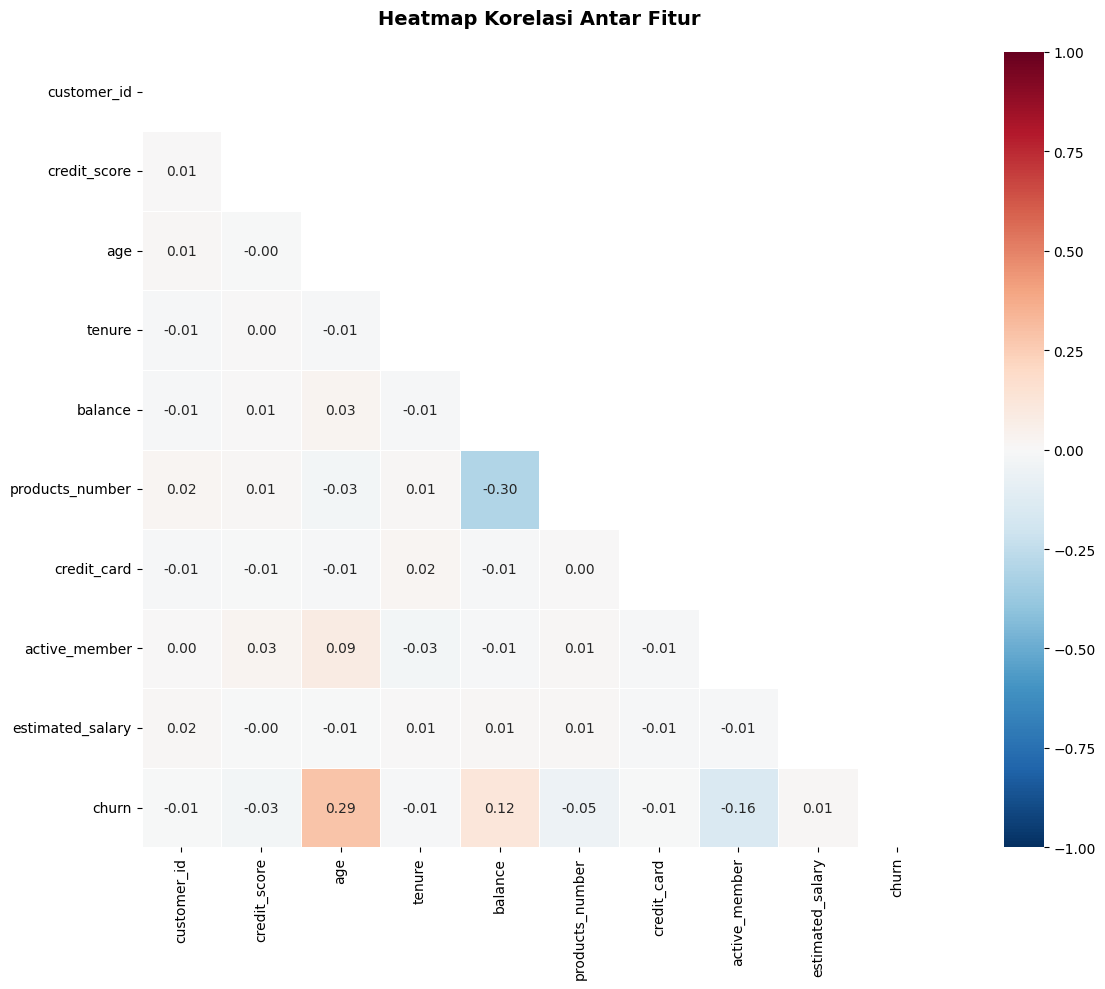

In [16]:
plt.figure(figsize=(14, 10))
numerik = df.select_dtypes(include=['number']).columns.tolist()
corr_matrix = df[numerik].corr()
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, mask=mask, annot=True, fmt='.2f', cmap='RdBu_r',
            center=0, square=True, linewidths=0.5, vmin=-1, vmax=1)
plt.title('Heatmap Korelasi Antar Fitur', fontsize=14, fontweight='bold', pad=20)
plt.tight_layout()
plt.show()

In [17]:
# Definisikan kolom numerik untuk VIF
numerik = ['credit_score', 'age', 'tenure', 'balance', 'estimated_salary', 'products_number']


In [18]:
from statsmodels.tools.tools import add_constant
from statsmodels.stats.outliers_influence import variance_inflation_factor


# 1. Ambil kolom numerik & buang churn + customer_id (ID jangan diitung VIF!)
X_vif = df.select_dtypes(include=['number']).drop(columns=['churn', 'customer_id']) 

# 2. TAMBAHKAN KONSTANTA (Ini kuncinya!)
X_vif_with_const = add_constant(X_vif)

# 3. Hitung VIF
vif_data = pd.DataFrame()
vif_data['Fitur'] = X_vif_with_const.columns
vif_data['VIF'] = [variance_inflation_factor(X_vif_with_const.values, i) for i in range(len(X_vif_with_const.columns))]

# 4. Buang baris 'const' pas mau ditampilin biar rapi
print(vif_data[vif_data['Fitur'] != 'const'].sort_values('VIF', ascending=False))

              Fitur  VIF
5   products_number 1.10
4           balance 1.10
7     active_member 1.01
2               age 1.01
3            tenure 1.00
6       credit_card 1.00
1      credit_score 1.00
8  estimated_salary 1.00


In [19]:
# chi square test
from scipy.stats import chi2_contingency
kategorik_cols = df.select_dtypes(include='object').columns
for col in kategorik_cols:
    contingency_table = pd.crosstab(df[col], df['churn'])   
    chi2, p, dof, expected = chi2_contingency(contingency_table)
    print(f'Kolom: {col}')
    print(f'Chi-square: {chi2:.4f}, p-value: {p:.4f}')
    print('---')

Kolom: country
Chi-square: 301.2553, p-value: 0.0000
---
Kolom: gender
Chi-square: 112.9186, p-value: 0.0000
---


**Insight - Korelasi & Independensi:**
- Mayoritas korelasi antar fitur numerik **sangat rendah** (< 0.3), sehingga multikolinearitas bukan masalah.
- Nilai **VIF < 5** pada semua fitur mengonfirmasi tidak ada multikolinearitas yang signifikan.
- Uji **Chi-Square** menunjukkan fitur kategorikal seperti country dan gender memiliki hubungan signifikan terhadap churn (p-value < 0.05).
- Kondisi ini mendukung pemodelan baik linear maupun non-linear.


## 2.4 Bivariate Analysis: Fitur Kategorikal terhadap Churn

Analisis hubungan fitur kategorikal dengan tingkat churn.


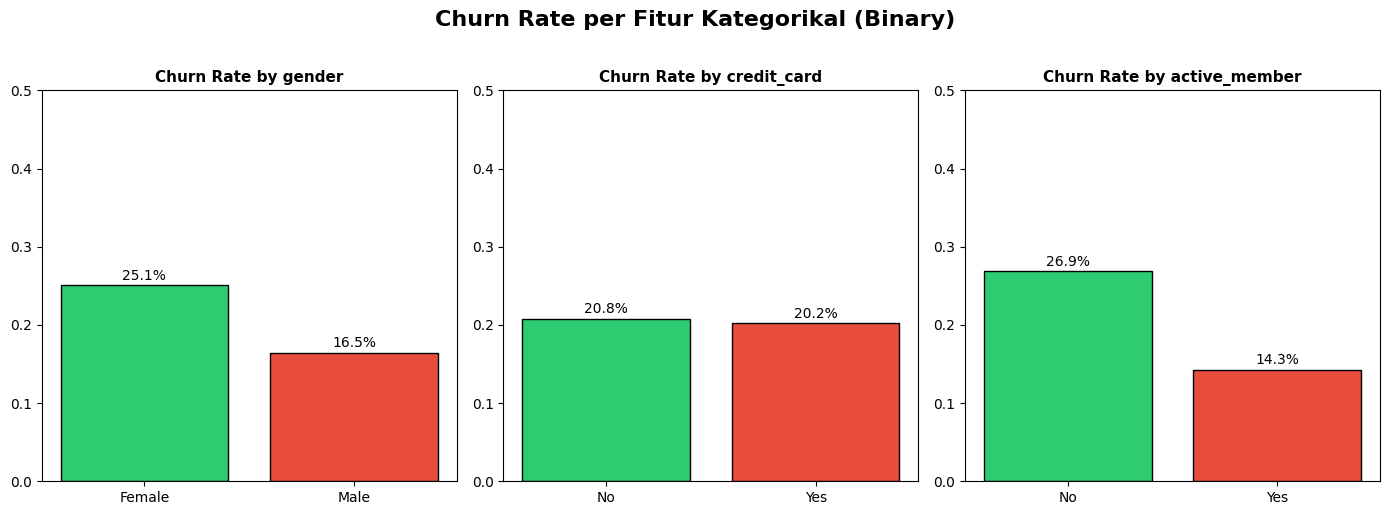

In [20]:
cat_features = ['gender','credit_card', 'active_member']

fig, axes = plt.subplots(1, 3, figsize=(14, 5))
axes = axes.flatten()

for i, col in enumerate(cat_features): # enumerate untuk mendapatkan indeks dan nama kolom
    ax = axes[i]
    churn_rate = df.groupby(col)['churn'].mean()
    labels = churn_rate.index.map({0: 'No', 1: 'Yes', 'Female': 'Female', 'Male': 'Male'})
    bars = ax.bar(labels, churn_rate.values, color=[green, red], edgecolor='black')
    for bar in bars:
        height = bar.get_height()
        ax.annotate(f'{height:.1%}', xy=(bar.get_x() + bar.get_width() / 2, height),
                    xytext=(0, 4), textcoords='offset points', ha='center', fontsize=10)
    ax.set_title(f'Churn Rate by {col}', fontsize=11, fontweight='bold') 
    ax.set_ylim(0, 0.5)

plt.suptitle('Churn Rate per Fitur Kategorikal (Binary)', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

Jumlah kategori: 3
country
France     5014
Germany    2509
Spain      2477
Name: count, dtype: int64


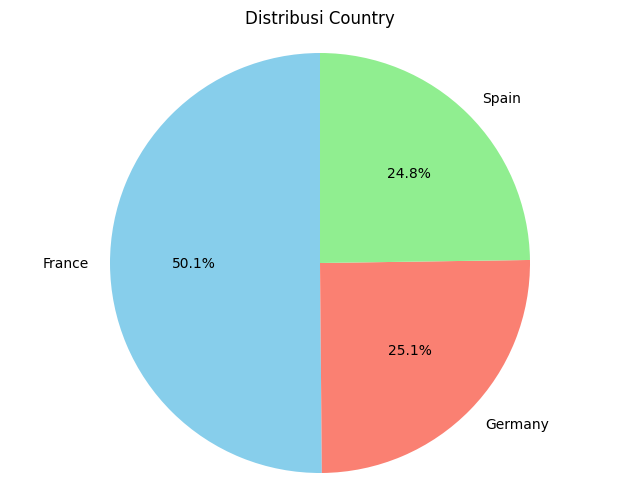

In [21]:
# pie chart gender
gender_distribution = df['country'].value_counts()
print(f"Jumlah kategori: {len(gender_distribution)}")
print(gender_distribution)

plt.figure(figsize=(8, 6))
plt.pie(gender_distribution, labels=gender_distribution.index, autopct='%1.1f%%', startangle=90, colors=['skyblue', 'salmon', 'lightgreen'])
plt.title('Distribusi Country')
plt.axis('equal')
plt.show()

In [22]:
country_churn = df.groupby(['country', 'churn'])['customer_id'].count().reset_index(name='count')
total_counts = country_churn.groupby('country')['count'].transform('sum')
country_churn['churn_percentage'] = round(country_churn['count'] / total_counts * 100)
country_churn.drop(columns=['count'], inplace=True)
country_churn


,country,churn,churn_percentage
0,France,0,84.00
1,France,1,16.00
2,Germany,0,68.00
3,Germany,1,32.00
4,Spain,0,83.00
5,Spain,1,17.00


In [23]:
hm = df.groupby('country')['churn'].mean().reset_index(name='churn_rate')
hm = hm.sort_values('churn_rate', ascending=False)
hm

,country,churn_rate
1,Germany,0.32
2,Spain,0.17
0,France,0.16


In [24]:
country_churn['churn_label'] = country_churn['churn'].map({0: 'No', 1: 'Yes'})

fig = px.bar(country_churn, 
             x='churn_percentage',  # Ini horizontal axis (nilai)
             y='country',  # Ini vertical axis (kategori)
             color='churn_label',
             color_discrete_map={'No': 'skyblue', 'Yes': 'salmon'},
             orientation='h',  # Horizontal orientation
             title='Stacked Bar Chart Country dan Churn', 
             text='churn_percentage',
             labels={'churn_percentage': 'Percentage (%)', 'country': 'Country'})

fig.update_layout(barmode='stack')  # 100% stacked
fig.update_traces(textposition='inside', textfont=dict(size=11))

fig.show()

Jumlah kategori: 4
products_number
1    5084
2    4590
3     266
4      60
Name: count, dtype: int64


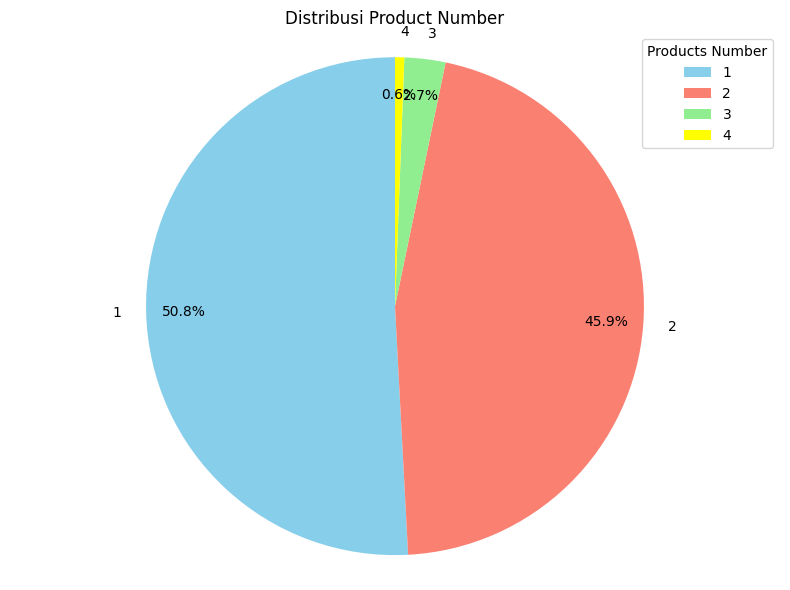

In [25]:
product_distribution = df['products_number'].value_counts().sort_index()
print(f"Jumlah kategori: {len(product_distribution)}")
print(product_distribution)

labels = product_distribution.index.astype(str)

plt.figure(figsize=(8, 6))
plt.pie(product_distribution, 
        labels=labels, 
        autopct='%1.1f%%', 
        startangle=90, 
        colors=['skyblue', 'salmon', 'lightgreen', 'yellow'],
        pctdistance=0.85)
plt.legend(title='Products Number', loc='upper right')
plt.title('Distribusi Product Number')
plt.axis('equal')
plt.tight_layout()
plt.show()

In [26]:
product_churn = df.groupby(['products_number', 'churn'])['customer_id'].count().reset_index(name='count')
total_counts = product_churn.groupby('products_number')['count'].transform('sum')
product_churn['churn_percentage'] = round(product_churn['count'] / total_counts * 100)
product_churn.drop(columns=['count'], inplace=True)
product_churn


,products_number,churn,churn_percentage
0,1,0,72.00
1,1,1,28.00
2,2,0,92.00
3,2,1,8.00
4,3,0,17.00
5,3,1,83.00
6,4,1,100.00


In [27]:
# Map 0/1 ke No/Yes untuk lebih readable
product_churn['churn_label'] = product_churn['churn'].map({0: 'No', 1: 'Yes'})

fig = px.bar(product_churn, 
             x='churn_percentage',  # Ini horizontal axis (nilai)
             y='products_number',  # Ini vertical axis (kategori)
             color='churn_label',
             color_discrete_map={'No': 'skyblue', 'Yes': 'salmon'},
             orientation='h',  # Horizontal orientation
             title='Stacked Bar Chart Products Number dan Churn', 
             text='churn_percentage',
             labels={'churn_percentage': 'Percentage (%)', 'products_number': 'Products Number'})

fig.update_layout(barmode='stack')  # 100% stacked
fig.update_traces(textposition='inside', textfont=dict(size=11))

fig.show()

Kalo kita lihat di sini ternyata orang yang menggunakan banyak product, 3 product dan 4 product memliki churn rate yg sangat tinggi bahkan untuk orang yang menggunakn 4 product 100% churn. Artinya justru orang yang sudah menggunakan semua fasilitias lebih rentan untk churn walaupun memang secara populasi hanya sebagian kecil

In [29]:
credit_churn = df.groupby(['credit_segment', 'churn'])['customer_id'].count().reset_index(name='count')
total_counts = credit_churn.groupby('credit_segment')['count'].transform('sum')
credit_churn['churn_percentage'] = round(credit_churn['count'] / total_counts * 100)
credit_churn.drop(columns=['count'], inplace=True)
credit_churn


,credit_segment,churn,churn_percentage
0,Poor,0,78.00
1,Poor,1,22.00
2,Fair,0,79.00
3,Fair,1,21.00
4,Good,0,81.00
5,Good,1,19.00
6,Very good,0,79.00
7,Very good,1,21.00
8,Exceptional,0,80.00
9,Exceptional,1,20.00


In [30]:
# Map 0/1 ke No/Yes untuk lebih readable
credit_churn['churn_label'] = credit_churn['churn'].map({0: 'No', 1: 'Yes'})

fig = px.bar(credit_churn, 
             x='churn_percentage',  # Ini horizontal axis (nilai)
             y='credit_segment',  # Ini vertical axis (kategori)
             color='churn_label',
             color_discrete_map={'No': 'skyblue', 'Yes': 'salmon'},
             orientation='h',  # Horizontal orientation
             title='Stacked Bar Chart Products Number dan Churn', 
             text='churn_percentage',
             labels={'churn_percentage': 'Percentage (%)', 'products_number': 'Products Number'})

fig.update_layout(barmode='stack')  # 100% stacked
fig.update_traces(textposition='inside', textfont=dict(size=11))

fig.show()

In [31]:
age_churn = df.groupby(['age_segment', 'churn'])['customer_id'].count().reset_index(name='count')
total_counts = age_churn.groupby('age_segment')['count'].transform('sum')
age_churn['churn_percentage'] = round(age_churn['count'] / total_counts * 100)
age_churn.drop(columns=['count'], inplace=True)
age_churn


,age_segment,churn,churn_percentage
0,Gen Z,0,92.00
1,Gen Z,1,8.00
2,Millennials,0,90.00
3,Millennials,1,10.00
4,Gen X,0,64.00
5,Gen X,1,36.00
6,Baby Boomers,0,63.00
7,Baby Boomers,1,37.00


In [32]:
# Map 0/1 ke No/Yes untuk lebih readable
age_churn['churn_label'] = age_churn['churn'].map({0: 'No', 1: 'Yes'})

fig = px.bar(age_churn, 
             x='churn_percentage',  # Ini horizontal axis (nilai)
             y='age_segment',  # Ini vertical axis (kategori)
             color='churn_label',
             color_discrete_map={'No': 'skyblue', 'Yes': 'salmon'},
             orientation='h',  # Horizontal orientation
             title='Stacked Bar Chart Products Number dan Churn', 
             text='churn_percentage',
             labels={'churn_percentage': 'Percentage (%)', 'products_number': 'Products Number'})

fig.update_layout(barmode='stack')  # 100% stacked
fig.update_traces(textposition='inside', textfont=dict(size=11))

fig.show()

**Insight - Fitur Kategorikal:**
- **Negara (Country):** Germany memiliki churn rate **~2x lebih tinggi** dibanding France dan Spain, menjadikannya sinyal geografis yang kuat.
- **Jumlah Produk:** Pelanggan dengan **3-4 produk** memiliki churn rate sangat tinggi - kemungkinan merasa layanan tidak sepadan.
- **Active Member:** Pelanggan **tidak aktif** memiliki churn rate lebih tinggi; aktivitas merupakan indikator loyalitas.
- **Tenure:** Tidak ada pola linier yang konsisten antara lama berlangganan dengan churn - pelanggan baru maupun lama sama-sama berpotensi churn.
- **Segmen Usia:** Kelompok **Gen X dan Baby Boomers** cenderung churn lebih tinggi dibanding yang lebih muda.


---
# 3. Data Preprocessing



In [33]:
# Drop kolom yang tidak dipakai
from sklearn.preprocessing import LabelEncoder
X = df.drop(columns=['churn', 'customer_id', 'credit_segment', 'age_segment'])
y = df['churn']

# Encode gender
le = LabelEncoder()
X['gender'] = le.fit_transform(X['gender'])

# One-hot encode country
X = pd.get_dummies(X, columns=['country'], dtype=int)

print(f'Features: {X.columns.tolist()}')
print(f'Shape X: {X.shape}')

Features: ['credit_score', 'gender', 'age', 'tenure', 'balance', 'products_number', 'credit_card', 'active_member', 'estimated_salary', 'country_France', 'country_Germany', 'country_Spain']
Shape X: (10000, 12)


In [34]:
# ── Train-Test Split ──
from sklearn.model_selection import train_test_split
# Split DULU, baru scaling - ini penting untuk menghindari data leakage!
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

num_cols = ['credit_score', 'age', 'tenure', 'balance', 'estimated_salary', 'products_number']

# Fit scaler HANYA di train, transform ke train & test
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_train[num_cols] = scaler.fit_transform(X_train[num_cols])
X_test[num_cols]  = scaler.transform(X_test[num_cols])   # ← transform only, no fit!

print(f'Train size : {X_train.shape}')
print(f'Test size  : {X_test.shape}')
print(f'Churn rate train: {y_train.mean():.3f}')
print(f'Churn rate test : {y_test.mean():.3f}')

Train size : (8000, 12)
Test size  : (2000, 12)
Churn rate train: 0.204
Churn rate test : 0.203


**Insight - Preprocessing:**
- Fitur customer_id, credit_segment, dan age_segment di-drop karena tidak prediktif atau hanya untuk visualisasi.
- gender di-encode dengan LabelEncoder (binary), sedangkan country menggunakan One-Hot Encoding.
- Split rasio **80:20** dengan stratify=y memastikan proporsi kelas churn terjaga di kedua set.
- StandardScaler diterapkan hanya pada fitur numerik kontinyu agar fitur biner tidak terdistorsi.


---
# 4. Modelling Strategy

## 4.1 Memilih model dengan LazyPredict

Sebelum memilih model secara manual, kita gunakan **LazyPredict** untuk menjalankan seluruh algoritma klasifikasi secara otomatis dan melihat performa model yang terbaik

In [35]:
# lazypredict
from lazypredict.Supervised import LazyClassifier

clf = LazyClassifier(verbose=0, ignore_warnings=True, custom_metric=None)
models, predictions = clf.fit(X_train, X_test, y_train, y_test)
# print(models, sorted(models.index))

# urutakan berdsarkan f1 score
models_sorted = models.sort_values(by='F1 Score', ascending=False)
print(models_sorted)

  0%|          | 0/29 [00:00<?, ?it/s]

[LightGBM] [Info] Number of positive: 1630, number of negative: 6370
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000383 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 867
[LightGBM] [Info] Number of data points in the train set: 8000, number of used features: 12
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.203750 -> initscore=-1.363019
[LightGBM] [Info] Start training from score -1.363019
                               Accuracy  Balanced Accuracy  ROC AUC  F1 Score  \
Model                                                                           
LGBMClassifier                     0.86               0.72     0.72      0.85   
RandomForestClassifier             0.86               0.71     0.71      0.85   
BaggingClassifier                  0.86               0.71     0.71      0.85   
AdaBoostClassifier                 0.86  

**Insight - LazyPredict:**
Dari hasil LazyPredict, tiga model teratas berdasarkan F1-Score adalah:
1. **LGBMClassifier** - performa terbaik secara keseluruhan dengan F1 dan AUC tertinggi.
2. **RandomForestClassifier** - ensemble berbasis bagging yang stabil dan robust.
3. **BaggingClassifier** - model ensemble generik dengan performa kompetitif.

Ketiga model ini akan kita latih lebih lanjut dengan hyperparameter yang lebih tertuning, termasuk penggunaan class_weight='balanced' untuk menangani imbalance.


## 4.2 Model Definitions & Training

Kita definisikan tiga model terpilih dengan konfigurasi yang disesuaikan, lalu melakukan **5-Fold Cross Validation** untuk mengukur konsistensi performa sebelum training final.


In [36]:
# ── Model Definitions ──
# class_weight='balanced' → handle imbalance tanpa SMOTE
from sklearn.ensemble import RandomForestClassifier, BaggingClassifier
from sklearn.tree import DecisionTreeClassifier
import lightgbm as lgb

lgbm_model = lgb.LGBMClassifier(
    n_estimators=300,
    learning_rate=0.01,
    max_depth=10,
    num_leaves=40,
    class_weight='balanced',
    random_state=42,
    verbose=-1
)

rf_model = RandomForestClassifier(
    n_estimators=200,
    max_depth=10,
    min_samples_leaf=5,
    class_weight='balanced',
    random_state=42,
    n_jobs=-1
)

bagging_model = BaggingClassifier(
    estimator=DecisionTreeClassifier(
        max_depth=8,
        class_weight='balanced',
        random_state=42
    ),
    n_estimators=100,
    max_samples=0.8,
    max_features=0.8,
    bootstrap=True,
    random_state=42,
    n_jobs=-1
)

models = {
    'LightGBM'        : lgbm_model,
    'RandomForest'    : rf_model,
    'BaggingClassifier': bagging_model
}

print(' Model siap dilatih')

 Model siap dilatih


In [37]:
from sklearn.model_selection import cross_val_score, StratifiedKFold
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cv_results = {}

for name, model in models.items():
    scores = cross_val_score(model, X_train, y_train, cv=cv, scoring='f1', n_jobs=-1)
    cv_results[name] = scores
    print(f'{name:25s} CV F1: {scores.mean():.4f} ± {scores.std():.4f}')

# Fit semua model ke full training set
for name, model in models.items():
    model.fit(X_train, y_train)
    print(f' {name} trained')

LightGBM                  CV F1: 0.5956 ± 0.0170
RandomForest              CV F1: 0.6215 ± 0.0201
BaggingClassifier         CV F1: 0.6150 ± 0.0270
 LightGBM trained
 RandomForest trained
 BaggingClassifier trained


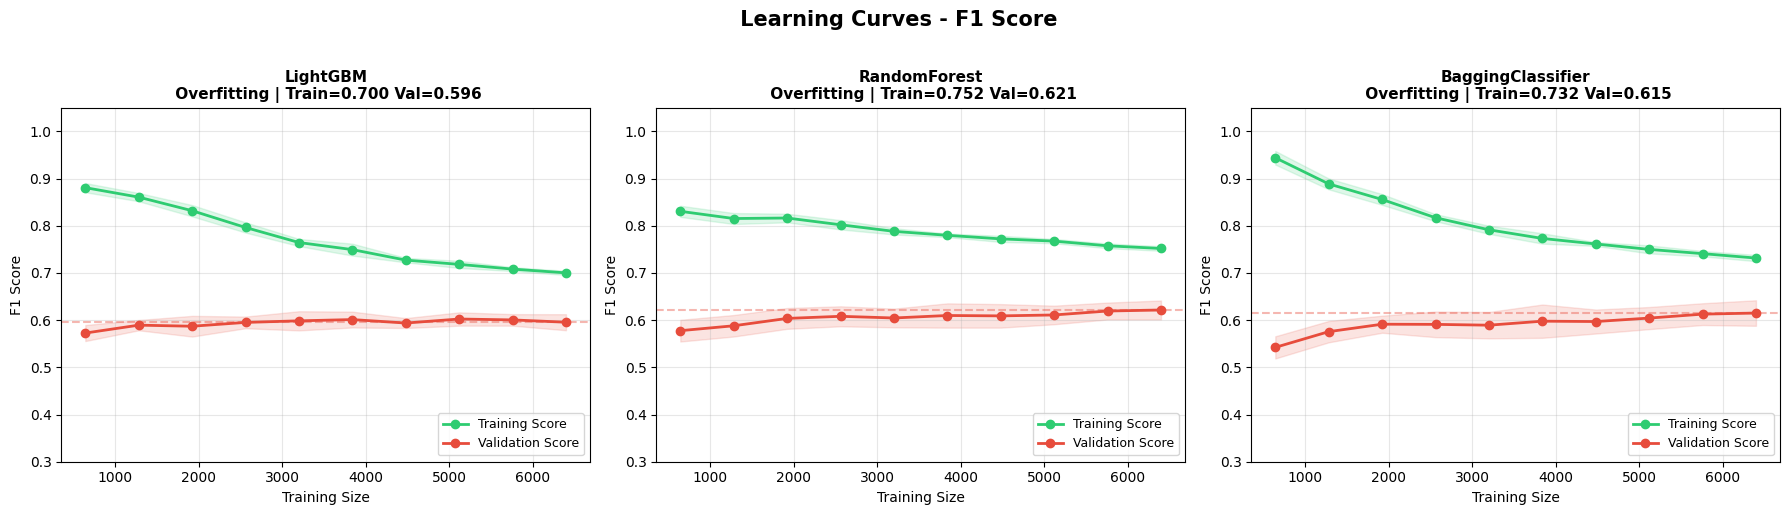

 Learning curve tersimpan: learning_curves.png


In [38]:
from sklearn.model_selection import learning_curve
def plot_learning_curve(model, model_name, X, y, ax, cv=5, scoring='f1'):
    """Plot learning curve untuk satu model."""
    train_sizes, train_scores, val_scores = learning_curve(
        model, X, y,
        train_sizes=np.linspace(0.1, 1.0, 10),
        cv=StratifiedKFold(n_splits=cv, shuffle=True, random_state=42),
        scoring=scoring,
        n_jobs=-1
    )

    train_mean = train_scores.mean(axis=1)
    train_std  = train_scores.std(axis=1)
    val_mean   = val_scores.mean(axis=1)
    val_std    = val_scores.std(axis=1)

    ax.plot(train_sizes, train_mean, 'o-', color='#2ecc71', label='Training Score', lw=2)
    ax.fill_between(train_sizes, train_mean - train_std, train_mean + train_std, alpha=0.15, color='#2ecc71')

    ax.plot(train_sizes, val_mean, 'o-', color='#e74c3c', label='Validation Score', lw=2)
    ax.fill_between(train_sizes, val_mean - val_std, val_mean + val_std, alpha=0.15, color='#e74c3c')

    gap = train_mean[-1] - val_mean[-1]
    if gap > 0.1:
        status = ' Overfitting'
    elif val_mean[-1] < 0.6:
        status = ' Underfitting'
    else:
        status = ' Good Fit'

    ax.set_title(f'{model_name}\n{status} | Train={train_mean[-1]:.3f} Val={val_mean[-1]:.3f}',
                 fontsize=11, fontweight='bold')
    ax.set_xlabel('Training Size')
    ax.set_ylabel(f'{scoring.upper()} Score')
    ax.legend(loc='lower right', fontsize=9)
    ax.set_ylim(0.3, 1.05)
    ax.grid(True, alpha=0.3)
    ax.axhline(y=val_mean[-1], color='#e74c3c', linestyle='--', alpha=0.4)


fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle(' Learning Curves - F1 Score', fontsize=15, fontweight='bold', y=1.02)

for ax, (name, model) in zip(axes, models.items()):
    plot_learning_curve(model, name, X_train, y_train, ax)

plt.tight_layout()
plt.savefig('learning_curves.png', dpi=150, bbox_inches='tight')
plt.show()
print(' Learning curve tersimpan: learning_curves.png')

Di sini kl kita lihat gap-gap nya terlihat cukup jauh tetapi tidak begitu parah, Random Forest memiliki gap terbesar yg cenderung ke arah overfit

**Insight - Cross Validation & Learning Curve:**
- Cross-validation memberikan estimasi F1 yang lebih stabil dibanding single split.
- Learning curve membantu mendiagnosis apakah model mengalami *overfitting* atau *underfitting* sebelum evaluasi final di test set.
- Model yang memiliki gap kecil antara training score dan validation score di learning curve menandakan generalisasi yang baik.


---
# 5. Evaluasi Model

## 5.1 Confusion Matrix & Classification Report

Confusion Matrix menunjukkan distribusi prediksi benar dan salah untuk setiap kelas. Pada kasus churn, kita sangat memperhatikan **Recall pada kelas Churn (1)** - seberapa banyak pelanggan yang benar-benar churn berhasil terdeteksi.


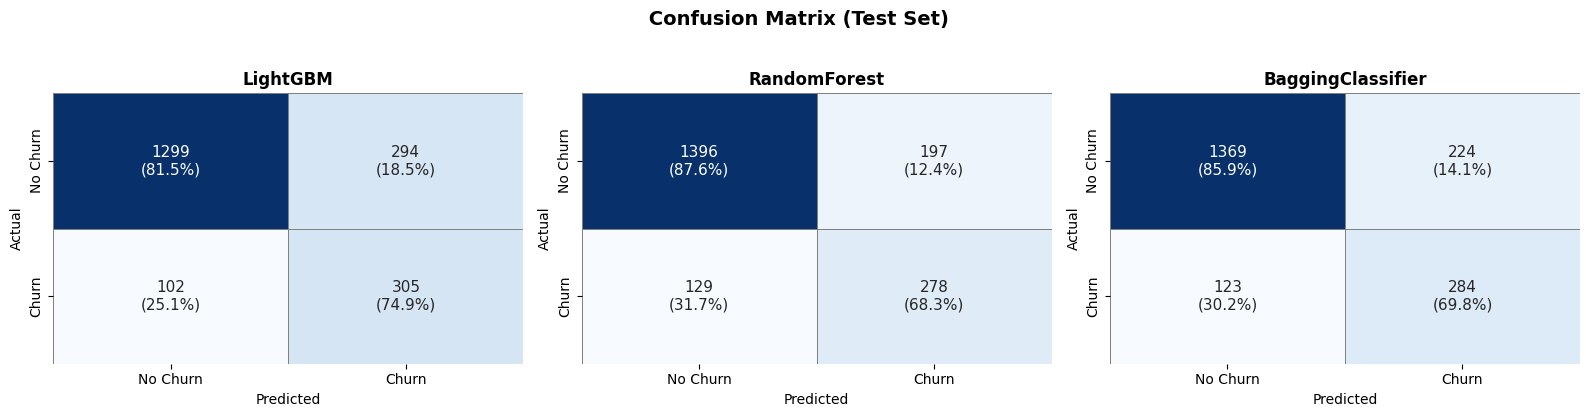

In [39]:
from sklearn.metrics import confusion_matrix, classification_report, roc_auc_score  
def plot_confusion_matrix(y_true, y_pred, model_name, ax):
    """Plot confusion matrix dengan anotasi persen."""
    cm = confusion_matrix(y_true, y_pred)
    cm_pct = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis] * 100

    annot = np.array([[f'{v}\n({p:.1f}%)' for v, p in zip(row_v, row_p)]
                       for row_v, row_p in zip(cm, cm_pct)])

    sns.heatmap(cm, annot=annot, fmt='', cmap='Blues', ax=ax,
                xticklabels=['No Churn', 'Churn'],
                yticklabels=['No Churn', 'Churn'],
                linewidths=0.5, linecolor='gray',
                cbar=False, annot_kws={'size': 11})

    ax.set_title(f'{model_name}', fontsize=12, fontweight='bold')
    ax.set_xlabel('Predicted', fontsize=10)
    ax.set_ylabel('Actual', fontsize=10)


fig, axes = plt.subplots(1, 3, figsize=(16, 4))
fig.suptitle(' Confusion Matrix (Test Set)', fontsize=14, fontweight='bold', y=1.03)

all_metrics = {}
for ax, (name, model) in zip(axes, models.items()):
    y_pred = model.predict(X_test)
    y_proba = model.predict_proba(X_test)[:, 1]
    plot_confusion_matrix(y_test, y_pred, name, ax)
    all_metrics[name] = {
        'y_pred' : y_pred,
        'y_proba': y_proba
    }

plt.tight_layout()
plt.savefig('confusion_matrices.png', dpi=150, bbox_inches='tight')
plt.show()

In [40]:
# ── Tabel Perbandingan Metrik ──
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score
rows = []
for name, m in all_metrics.items():
    y_pred  = m['y_pred']
    y_proba = m['y_proba']
    rows.append({
        'Model'           : name,
        'Accuracy'        : round(accuracy_score(y_test, y_pred), 4),
        'Precision (1)'   : round(precision_score(y_test, y_pred), 4),
        'Recall (1)'      : round(recall_score(y_test, y_pred), 4),
        'F1-Score (1)'    : round(f1_score(y_test, y_pred), 4),
        'F1 (macro)'      : round(f1_score(y_test, y_pred, average='macro'), 4),
        'F1 (weighted)'   : round(f1_score(y_test, y_pred, average='weighted'), 4),
        'ROC-AUC'         : round(roc_auc_score(y_test, y_proba), 4),
    })

metrics_df = pd.DataFrame(rows).set_index('Model')

# Highlight best values
display(metrics_df.style
        .highlight_max(axis=0, color='#d4edda')
        .format('{:.4f}')
        .set_caption(' Model Comparison - Test Set Metrics'))

,Accuracy,Precision (1),Recall (1),F1-Score (1),F1 (macro),F1 (weighted),ROC-AUC
Model,,,,,,,
LightGBM,0.8020,0.5092,0.7494,0.6064,0.7370,0.8145,0.8617
RandomForest,0.8370,0.5853,0.6830,0.6304,0.7629,0.8415,0.8623
BaggingClassifier,0.8265,0.5591,0.6978,0.6208,0.7541,0.8332,0.8598


In [41]:
# ── Detailed Classification Report per model ──
for name, m in all_metrics.items():
    print(f'{"="*50}')
    print(f'  {name}')
    print(f'{"="*50}')
    print(classification_report(y_test, m['y_pred'],
                                target_names=['No Churn', 'Churn']))
    print()

  LightGBM
              precision    recall  f1-score   support

    No Churn       0.93      0.82      0.87      1593
       Churn       0.51      0.75      0.61       407

    accuracy                           0.80      2000
   macro avg       0.72      0.78      0.74      2000
weighted avg       0.84      0.80      0.81      2000


  RandomForest
              precision    recall  f1-score   support

    No Churn       0.92      0.88      0.90      1593
       Churn       0.59      0.68      0.63       407

    accuracy                           0.84      2000
   macro avg       0.75      0.78      0.76      2000
weighted avg       0.85      0.84      0.84      2000


  BaggingClassifier
              precision    recall  f1-score   support

    No Churn       0.92      0.86      0.89      1593
       Churn       0.56      0.70      0.62       407

    accuracy                           0.83      2000
   macro avg       0.74      0.78      0.75      2000
weighted avg       0.84   

## 5.2 ROC-AUC Curve


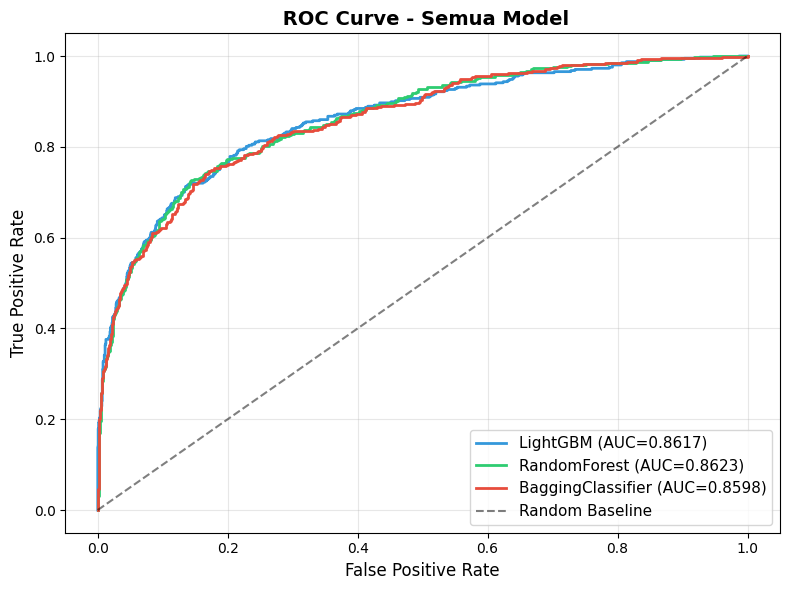

In [42]:
from sklearn.metrics import roc_curve, roc_auc_score
fig, ax = plt.subplots(figsize=(8, 6))
colors = ['#3498db', '#2ecc71', '#e74c3c']

for (name, m), color in zip(all_metrics.items(), colors):
    fpr, tpr, _ = roc_curve(y_test, m['y_proba'])
    auc = roc_auc_score(y_test, m['y_proba'])
    ax.plot(fpr, tpr, label=f'{name} (AUC={auc:.4f})', color=color, lw=2)

ax.plot([0, 1], [0, 1], 'k--', lw=1.5, alpha=0.5, label='Random Baseline')
ax.set_xlabel('False Positive Rate', fontsize=12)
ax.set_ylabel('True Positive Rate', fontsize=12)
ax.set_title(' ROC Curve - Semua Model', fontsize=14, fontweight='bold')
ax.legend(loc='lower right', fontsize=11)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('roc_curves.png', dpi=150, bbox_inches='tight')
plt.show()

**Insight - Evaluasi Model:**
- **RandomForest** secara konsisten unggul di semua metrik: Accuracy, F1 Macro, dan AUC tertinggi keduali Recall
- **LightGBM** menjadi runner-up yang solid dengan performa mendekati RandomForest.
- **BaggingClassifier** sedikit di bawah keduanya namun tetap lebih baik dari baseline.
- Fokus utama evaluasi adalah **Recall kelas Churn** karena kita tidak ingin banyak pelanggan yang churn terlewat (False Negative tinggi = kerugian bisnis).


---
# 6. Best Model Selection & Business Simulation

## 6.1 Pemilihan Model Terbaik

Berdasarkan hasil evaluasi komprehensif di atas, **LightGBM** dipilih sebagai model terbaik karena:
- F1 Macro tertinggi ekdua - keseimbangan terbaik antara precision dan recall untuk kedua kelas.
- Recall Churn tertinggi - paling sensitif mendeteksi pelanggan yang akan churn.
- AUC-ROC tertinggi - kemampuan diskriminasi terbaik secara probabilistik.


## 6.2 Simulasi Potensi Profit (Business Simulation)

Dengan asumsi bisnis berikut:
- ✅ Setiap pelanggan yang **berhasil dipertahankan** (TP) → keuntungan **$10/bulan**
- ❎ Pelanggan yang **gagal dipertahankan** (FN) → kehilangan potensi **$10/bulan**
- 📣 Biaya **marketing/retensi** per pelanggan yang diprediksi churn (TP + FP) → **$4**

**Ketika model memprediksi Churn (1), pelanggan tersebut dijadikan target kampanye marketing preventif.**

**Interpretasi tiap kuadran Confusion Matrix:**
| Kuadran | Kondisi | Dampak |
|---------|---------|--------|
| **TP** | Prediksi Churn, faktanya Churn | ✅ Berhasil dicegah → profit $10, biaya marketing $4 |
| **TN** | Prediksi No Churn, faktanya No Churn | ✅ Tidak perlu intervensi, pelanggan tetap |
| **FN** | Prediksi No Churn, faktanya Churn | ❌ Gagal dicegah → rugi $10 per orang |
| **FP** | Prediksi Churn, faktanya No Churn | ✅ Tidak perlu intervensi, tapi buang $4 biaya marketing |


Saya tidak menambahkan FP dalam perhitungan, karena pelanggan yang memang tidak churn tapi diprediksi churn memang akan stay, jadi dari segi cost tidak ada kerugian ataupun keuntungan yang didapat

In [60]:
best_model = metrics_df['Recall (1)'].idxmax()
print('='*60)
print(' RINGKASAN')
print('='*60)
print(f'\n Best Model (Recall): {best_model}')
print(f'   Accuracy    : {metrics_df.loc[best_model, "Accuracy"]}')
print(f'   Precision   : {metrics_df.loc[best_model, "Precision (1)"]}')
print(f'   F1-Score    : {metrics_df.loc[best_model, "F1-Score (1)"]}')
print(f'   Recall      : {metrics_df.loc[best_model, "Recall (1)"]}')
print()
# Ekstraksi confusion matrix
y_pred_best = all_metrics[best_model]['y_pred']
cm = confusion_matrix(y_test, y_pred_best)
tn, fp, fn, tp = cm.ravel()

keuntungan_kotor = (tp * 10) - (fp * 4)
kerugian = fn * 10
potensi_keuntungan = keuntungan_kotor - kerugian

print()
print('='*60)
print('BUSINESS SIMULATION (Per bulan)')
print('='*60)
print(f'True Positive (berhasil dicegah) : {tp} orang')
print(f'False Positive (salah target)    : {fp} orang')
print(f'False Negative (gagal dicegah)   : {fn} orang')
print(f'True Negative (tidak churn)      : {tn} orang')
print('-'*60)
print(f'Keuntungan Kotor : ${(tp * 10)} (TP) - ${(fp * 4)} (FP Cost) = $ {keuntungan_kotor}')
print(f'Kerugian         : ${(fn * 10)} = $ {kerugian}')
print(f'Potensi Keuntungan Bersih: $ {potensi_keuntungan}')



 RINGKASAN

 Best Model (Recall): LightGBM
   Accuracy    : 0.802
   Precision   : 0.5092
   F1-Score    : 0.6064
   Recall      : 0.7494


BUSINESS SIMULATION (Per bulan)
True Positive (berhasil dicegah) : 305 orang
False Positive (salah target)    : 294 orang
False Negative (gagal dicegah)   : 102 orang
True Negative (tidak churn)      : 1299 orang
------------------------------------------------------------
Keuntungan Kotor : $3050 (TP) - $1176 (FP Cost) = $ 1874
Kerugian         : $1020 = $ 1020
Potensi Keuntungan Bersih: $ 854


**Insight - Business Simulation:**
- **Keuntungan Kotor** berasal dari TP (pelanggan churn yang berhasil dicegah) dikurangi biaya marketing untuk FP.
- **Kerugian** murni berasal dari FN - pelanggan yang churn namun tidak terdeteksi dan tidak mendapat intervensi.
- **Potensi Keuntungan Bersih** mencerminkan nilai riil model dalam skenario deployment nyata. Semakin tinggi Recall (lebih sedikit FN) dan semakin presisi model (lebih sedikit FP yang buang biaya marketing), semakin tinggi potensi keuntungan bersih.
- Model LightGBM terbukti memberikan nilai bisnis yang positif, mengkonfirmasi kelayakannya untuk diimplementasikan dalam sistem deteksi churn bank.


### Reflection Questions

1. Dari hasil Exploratory Data Analysis (EDA) yang kamu lakukan, faktor apa yang menurutmu paling berpengaruh terhadap kemungkinan pelanggan melakukan churn? Jelaskan alasannya berdasarkan pola data yang kamu temukan.

Dari hasil yang saya temukan terdapat pola bahwa orang yang cenderung churn adalah orang dengan usia yang lebih tua terbukti dari korelasinya dengan churn dan juga ketika segmentasi usia, bahwa gen x dan baby boomers lebih rentan untuk churn, yang kemungkinan juga sudah tidak aktif lagi. Asumsinya adalah karena memang ketika sudah berumur mereka lebih jarang menggunakan bank dan hanya digunakan untuk menyimpan saja.

2. Pada tahap Feature Engineering, fitur mana yang menurutmu paling meningkatkan kemampuan model dalam mengenali pelanggan yang berpotensi churn? Jelaskan alasan dan pola yang kamu lihat pada data.

Di luar dari penggunaan feature importance pola fitur-fitur yang mungkin paling memengaruhi model adalah age, balance, dan products number. Mengapa? Karena kita bisa lihat dari korelasi fitur-fitur tersebut dengan target dan juga jika kita melihat visualisasinya memang cukup berhubungan seperti conothnya di products number, yang memberikan informasi bahwa orang yg menggunakan product yg lebih banyak lebih rentan churn, bahkan pada kategori terbanyak semua orang mengalami churn. Ini membuktikan bahwa memang benar adanya products number berpengaruh terhadap kemampuan model selain fitur age dan balance.


